In [8]:
import pandas as pd

customers = pd.read_csv('/content/customers.csv')
transactions = pd.read_csv('/content/transactions.csv')

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Customers: (500, 6)
Transactions: (500, 6)


In [21]:
import pandas as pd

transactions = pd.read_csv('/content/transactions.csv')

print("Transactions shape:", transactions.shape)
print("\nTransactions columns:")
print(transactions.columns.tolist())

Transactions shape: (5000, 9)

Transactions columns:
['transaction_id', 'customer_id', 'transaction_date', 'product', 'category', 'quantity', 'unit_price', 'total_amount', 'payment_method']


In [22]:
# Convert date columns to datetime

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

print("Date conversion successful!")

Date conversion successful!


In [23]:
# Check missing values

print("Missing values in Customers:")
print(customers.isnull().sum())

print("\nMissing values in Transactions:")
print(transactions.isnull().sum())

Missing values in Customers:
customer_id      0
customer_name    0
gender           0
age              0
city             0
signup_date      0
dtype: int64

Missing values in Transactions:
transaction_id      0
customer_id         0
transaction_date    0
product             0
category            0
quantity            0
unit_price          0
total_amount        0
payment_method      0
dtype: int64


In [24]:
# Check duplicate records

print("Duplicate customers:", customers.duplicated().sum())
print("Duplicate transactions:", transactions.duplicated().sum())

Duplicate customers: 0
Duplicate transactions: 0


In [25]:
# Set the analysis date as the latest transaction date
analysis_date = transactions['transaction_date'].max()

# Calculate RFM values
rfm = transactions.groupby('customer_id').agg(
    recency=('transaction_date',
             lambda x: (analysis_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('total_amount', 'sum')
).reset_index()

print("RFM analysis completed!")
print("Number of customers:", len(rfm))

RFM analysis completed!
Number of customers: 500


In [26]:
rfm.head(10)

,customer_id,recency,frequency,monetary
0,1,377,14,426400.0
1,2,510,12,108800.0
2,3,476,12,361500.0
3,4,425,12,529600.0
4,5,412,12,376000.0
5,6,402,11,90200.0
6,7,376,12,358000.0
7,8,349,11,591800.0
8,9,324,12,283400.0
9,10,298,11,150500.0


In [27]:
# Create RFM scores

rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

print("RFM scoring completed!")

RFM scoring completed!


In [28]:
rfm.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score
0,1,377,14,426400.0,4,5,4
1,2,510,12,108800.0,3,5,2
2,3,476,12,361500.0,3,5,4
3,4,425,12,529600.0,4,5,5
4,5,412,12,376000.0,4,5,4
5,6,402,11,90200.0,4,5,1
6,7,376,12,358000.0,4,5,4
7,8,349,11,591800.0,5,5,5
8,9,324,12,283400.0,5,5,2
9,10,298,11,150500.0,5,5,2


In [29]:
# Convert RFM scores to integers
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Create combined RFM score
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

print("Combined RFM score created successfully!")

Combined RFM score created successfully!


In [30]:
rfm.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,1,377,14,426400.0,4,5,4,454
1,2,510,12,108800.0,3,5,2,352
2,3,476,12,361500.0,3,5,4,354
3,4,425,12,529600.0,4,5,5,455
4,5,412,12,376000.0,4,5,4,454
5,6,402,11,90200.0,4,5,1,451
6,7,376,12,358000.0,4,5,4,454
7,8,349,11,591800.0,5,5,5,555
8,9,324,12,283400.0,5,5,2,552
9,10,298,11,150500.0,5,5,2,552


In [31]:
# Create customer segments

def assign_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value'
    elif row['F_score'] >= 4 and row['M_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['customer_segment'] = rfm.apply(assign_segment, axis=1)

print("Customer segmentation completed!")

Customer segmentation completed!


In [32]:
rfm[['customer_id', 'RFM_score', 'customer_segment']].head(10)

,customer_id,RFM_score,customer_segment
0,1,454,High Value
1,2,352,Potential Loyalists
2,3,354,Loyal Customers
3,4,455,High Value
4,5,454,High Value
5,6,451,Potential Loyalists
6,7,454,High Value
7,8,555,High Value
8,9,552,Potential Loyalists
9,10,552,Potential Loyalists


In [33]:
segment_counts = rfm['customer_segment'].value_counts()

print(segment_counts)

customer_segment
At Risk                150
Potential Loyalists    122
Others                 103
Loyal Customers         91
High Value              34
Name: count, dtype: int64


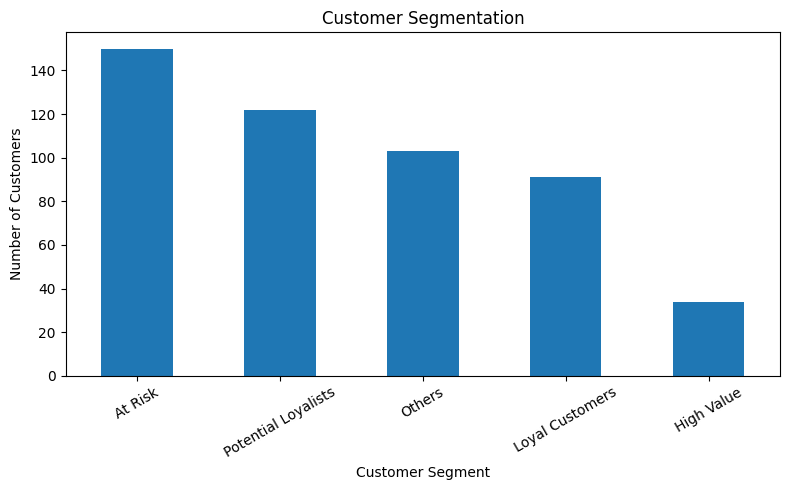

In [34]:
import matplotlib.pyplot as plt

segment_counts = rfm['customer_segment'].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar')

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [35]:
# Create purchase month
transactions['purchase_month'] = (
    transactions['transaction_date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

# Find each customer's first purchase month
transactions['cohort_month'] = (
    transactions.groupby('customer_id')['transaction_date']
    .transform('min')
    .dt.to_period('M')
    .dt.to_timestamp()
)

print("Cohort preparation completed!")

Cohort preparation completed!


In [36]:
transactions[
    ['customer_id', 'transaction_date',
     'purchase_month', 'cohort_month']
].head(10)

,customer_id,transaction_date,purchase_month,cohort_month
0,1,2025-01-20,2025-01-01,2025-01-01
1,2,2025-01-25,2025-01-01,2025-01-01
2,3,2025-02-10,2025-02-01,2025-02-01
3,1,2025-02-15,2025-02-01,2025-01-01
4,4,2025-02-25,2025-02-01,2025-02-01
5,5,2025-03-05,2025-03-01,2025-03-01
6,6,2025-03-18,2025-03-01,2025-03-01
7,7,2025-03-28,2025-03-01,2025-03-01
8,2,2025-04-05,2025-04-01,2025-01-01
9,8,2025-04-15,2025-04-01,2025-04-01


In [37]:
# Calculate the cohort month number

transactions['cohort_index'] = (
    (transactions['purchase_month'].dt.year -
     transactions['cohort_month'].dt.year) * 12
    +
    (transactions['purchase_month'].dt.month -
     transactions['cohort_month'].dt.month)
)

print("Cohort month number calculated successfully!")

Cohort month number calculated successfully!


In [38]:
transactions[
    ['customer_id', 'cohort_month',
     'purchase_month', 'cohort_index']
].head(10)

,customer_id,cohort_month,purchase_month,cohort_index
0,1,2025-01-01,2025-01-01,0
1,2,2025-01-01,2025-01-01,0
2,3,2025-02-01,2025-02-01,0
3,1,2025-01-01,2025-02-01,1
4,4,2025-02-01,2025-02-01,0
5,5,2025-03-01,2025-03-01,0
6,6,2025-03-01,2025-03-01,0
7,7,2025-03-01,2025-03-01,0
8,2,2025-01-01,2025-04-01,3
9,8,2025-04-01,2025-04-01,0


In [39]:
# Count unique active customers for each cohort and month

cohort_activity = (
    transactions
    .groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index(name='active_customers')
)

cohort_activity.head(10)

,cohort_month,cohort_index,active_customers
0,2024-01-01,0,11
1,2024-01-01,1,11
2,2024-01-01,2,11
3,2024-01-01,3,9
4,2024-01-01,4,7
5,2024-01-01,5,4
6,2024-01-01,6,2
7,2024-01-01,14,3
8,2024-01-01,15,5
9,2024-01-01,16,7


In [40]:
# Calculate the number of customers in each cohort

cohort_sizes = (
    transactions
    .groupby('cohort_month')['customer_id']
    .nunique()
    .reset_index(name='cohort_size')
)

cohort_sizes.head()

,cohort_month,cohort_size
0,2024-01-01,11
1,2024-02-01,29
2,2024-03-01,24
3,2024-04-01,27
4,2024-05-01,37


In [41]:
cohort_retention = cohort_activity.merge(
    cohort_sizes,
    on='cohort_month'
)

cohort_retention.head(10)

,cohort_month,cohort_index,active_customers,cohort_size
0,2024-01-01,0,11,11
1,2024-01-01,1,11,11
2,2024-01-01,2,11,11
3,2024-01-01,3,9,11
4,2024-01-01,4,7,11
5,2024-01-01,5,4,11
6,2024-01-01,6,2,11
7,2024-01-01,14,3,11
8,2024-01-01,15,5,11
9,2024-01-01,16,7,11


In [42]:
# Calculate retention percentage

cohort_retention['retention_rate'] = (
    cohort_retention['active_customers']
    / cohort_retention['cohort_size']
    * 100
)

cohort_retention['retention_rate'] = (
    cohort_retention['retention_rate'].round(2)
)

cohort_retention.head(10)

,cohort_month,cohort_index,active_customers,cohort_size,retention_rate
0,2024-01-01,0,11,11,100.00
1,2024-01-01,1,11,11,100.00
2,2024-01-01,2,11,11,100.00
3,2024-01-01,3,9,11,81.82
4,2024-01-01,4,7,11,63.64
5,2024-01-01,5,4,11,36.36
6,2024-01-01,6,2,11,18.18
7,2024-01-01,14,3,11,27.27
8,2024-01-01,15,5,11,45.45
9,2024-01-01,16,7,11,63.64


In [43]:
# Create cohort retention matrix

cohort_matrix = cohort_retention.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention_rate'
)

cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
cohort_month,,,,,,,,,,,,,,,,,,,
2024-01-01,100.0,100.00,100.00,81.82,63.64,36.36,18.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.27,45.45,63.64,81.82,NaN
2024-02-01,100.0,86.21,68.97,55.17,44.83,31.03,17.24,NaN,NaN,NaN,NaN,3.45,17.24,31.03,44.83,58.62,72.41,86.21,3.45
2024-03-01,100.0,95.83,83.33,62.50,54.17,41.67,29.17,NaN,NaN,NaN,NaN,NaN,8.33,20.83,37.50,50.00,58.33,70.83,8.33
2024-04-01,100.0,88.89,85.19,74.07,62.96,48.15,33.33,NaN,NaN,NaN,NaN,3.70,11.11,18.52,25.93,40.74,55.56,62.96,3.70
2024-05-01,100.0,89.19,81.08,70.27,62.16,48.65,29.73,NaN,NaN,NaN,NaN,NaN,8.11,18.92,27.03,35.14,45.95,59.46,NaN
2024-06-01,100.0,92.59,85.19,77.78,70.37,62.96,48.15,NaN,NaN,NaN,NaN,NaN,7.41,14.81,25.93,33.33,37.04,44.44,NaN
2024-07-01,100.0,92.31,84.62,76.92,69.23,65.38,53.85,NaN,NaN,NaN,NaN,NaN,7.69,15.38,23.08,34.62,34.62,42.31,3.85
2024-08-01,100.0,100.00,96.00,88.00,84.00,76.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,4.00,12.00,20.00,24.00,28.00,NaN
2024-09-01,100.0,93.33,90.00,83.33,76.67,70.00,60.00,NaN,NaN,NaN,NaN,3.33,6.67,10.00,16.67,26.67,33.33,40.00,NaN


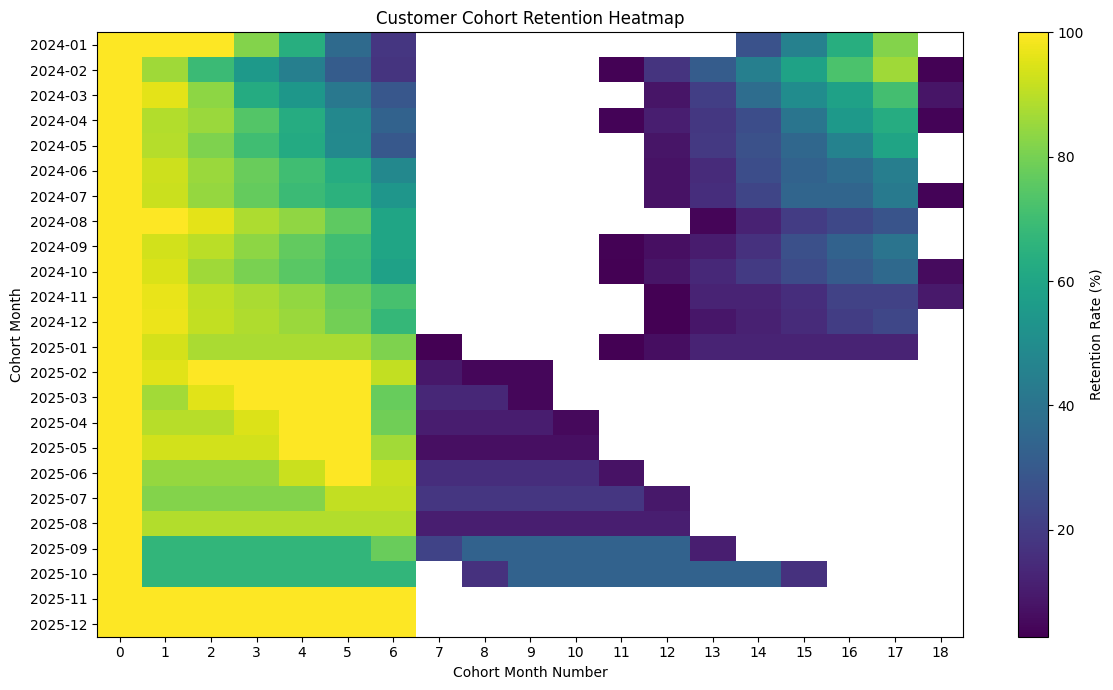

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.imshow(
    cohort_matrix,
    aspect='auto',
    interpolation='nearest'
)

plt.colorbar(label='Retention Rate (%)')

plt.title('Customer Cohort Retention Heatmap')
plt.xlabel('Cohort Month Number')
plt.ylabel('Cohort Month')

plt.xticks(
    range(len(cohort_matrix.columns)),
    cohort_matrix.columns
)

plt.yticks(
    range(len(cohort_matrix.index)),
    cohort_matrix.index.strftime('%Y-%m')
)

plt.tight_layout()
plt.show()

In [45]:
# Calculate average retention by cohort month number

average_retention = (
    cohort_retention
    .groupby('cohort_index')['retention_rate']
    .mean()
    .reset_index()
)

average_retention['retention_rate'] = (
    average_retention['retention_rate'].round(2)
)

average_retention

,cohort_index,retention_rate
0,0,100.00
1,1,90.57
2,2,87.36
3,3,82.93
4,4,79.86
5,5,75.33
6,6,65.80
7,7,12.22
8,8,14.45
9,9,15.29


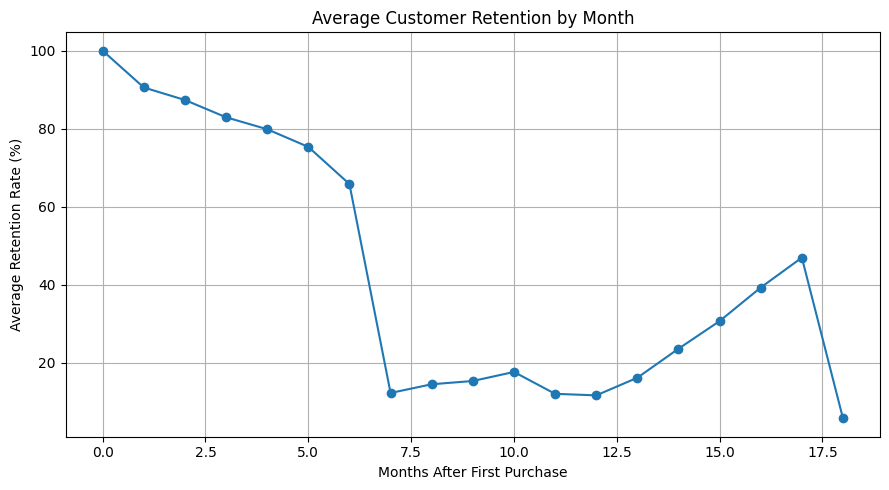

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    average_retention['cohort_index'],
    average_retention['retention_rate'],
    marker='o'
)

plt.title('Average Customer Retention by Month')
plt.xlabel('Months After First Purchase')
plt.ylabel('Average Retention Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
# Create final cohort summary

cohort_summary = (
    cohort_retention
    .groupby('cohort_month')
    .agg(
        cohort_size=('cohort_size', 'first'),
        average_retention=('retention_rate', 'mean'),
        latest_retention=('retention_rate', 'last')
    )
    .reset_index()
)

cohort_summary['average_retention'] = (
    cohort_summary['average_retention'].round(2)
)

cohort_summary['latest_retention'] = (
    cohort_summary['latest_retention'].round(2)
)

cohort_summary

,cohort_month,cohort_size,average_retention,latest_retention
0,2024-01-01,11,65.29,81.82
1,2024-02-01,29,48.05,3.45
2,2024-03-01,24,51.49,8.33
3,2024-04-01,27,47.65,3.70
4,2024-05-01,37,51.98,59.46
5,2024-06-01,27,53.85,44.44
6,2024-07-01,26,50.28,3.85
7,2024-08-01,25,57.67,28.00
8,2024-09-01,30,50.71,40.00
9,2024-10-01,36,47.04,5.56


## Week 2 – Final Findings and Conclusions

### RFM Analysis

- RFM analysis was used to evaluate customers based on Recency, Frequency, and Monetary value.
- RFM scores were calculated for each customer.
- Customers were divided into different segments based on their RFM scores.

### Customer Segmentation

- Customer segmentation helps identify customers with different purchasing behaviors.
- High Value and Loyal Customers represent important customer groups.
- At Risk customers can be targeted with suitable retention strategies.

### Cohort Analysis

- Cohort analysis was performed based on customers' first purchase month.
- Customer retention was calculated for different months after the first purchase.
- A cohort retention matrix and heatmap were created to visualize retention patterns.
- Average retention was calculated to understand the overall retention trend.

### Conclusion

The Week 2 analysis provides insights into customer behavior, customer value, segmentation, and retention patterns. RFM analysis helps identify different types of customers, while cohort analysis shows how customer engagement changes over time. These insights can support data-driven customer retention and marketing strategies.

## Week 2 – Submission Summary

### Completed Tasks

- Loaded and validated customer and transaction datasets.
- Performed RFM analysis using Recency, Frequency, and Monetary values.
- Calculated RFM scores for customers.
- Created customer segments based on RFM scores.
- Visualized customer segmentation.
- Performed customer cohort analysis.
- Calculated cohort month and cohort index.
- Created cohort retention tables and retention matrix.
- Generated a cohort retention heatmap.
- Calculated average customer retention by month.
- Visualized the average retention trend.
- Summarized the key findings from RFM and cohort analysis.

### Week 2 Outcome

The analysis provides insights into customer purchasing behavior, customer value, customer segments, and retention patterns. The results can be used to support customer retention and business decision-making.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')